In [2]:
import pandas as pd
import json

with open("/content/balanced_flight_telemetry.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
print(df.head())

              timestamp flight_info.callsign  flight_info.airframe_hours  \
0  2026-04-09T10:00:00Z           VIT-AI-400                14250.500000   
1  2026-04-09T10:00:01Z           VIT-AI-400                14250.500278   
2  2026-04-09T10:00:02Z           VIT-AI-400                14250.500556   
3  2026-04-09T10:00:03Z           VIT-AI-400                14250.500833   
4  2026-04-09T10:00:04Z           VIT-AI-400                14250.501111   

  flight_info.flight_phase  kinematics.altitude_ft  kinematics.airspeed_knots  \
0                  TAKEOFF                     0.0                     280.52   
1                  TAKEOFF                     0.0                     282.23   
2                  TAKEOFF                     0.0                     278.10   
3                  TAKEOFF                     0.0                     279.41   
4                  TAKEOFF                     0.0                     281.05   

   kinematics.g_force_axial  propulsion_sys.engine_1_egt

/tmp/ipykernel_13051/1222275819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='analytics_meta.maintenance_flag', data=df, ax=axes[0], palette='viridis')


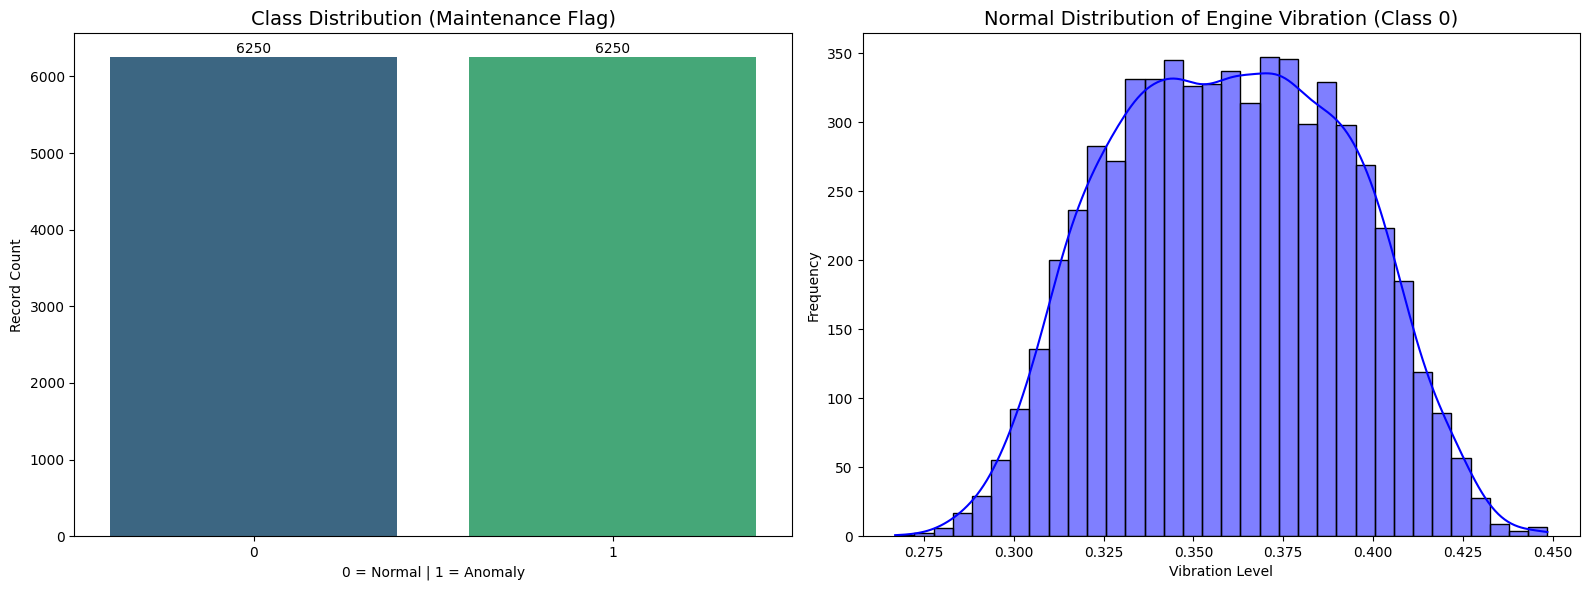

--- Data Summary ---
Total Vehicles: 5
Class Counts:
analytics_meta.maintenance_flag
0    6250
1    6250
Name: count, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# 1. Load the data
with open('balanced_flight_telemetry.json', 'r') as f:
    data = json.load(f)

# 2. Flatten JSON into a DataFrame
df = pd.json_normalize(data)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: Class Distribution (Bar Chart) ---
sns.countplot(x='analytics_meta.maintenance_flag', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution (Maintenance Flag)', fontsize=14)
axes[0].set_xlabel('0 = Normal | 1 = Anomaly')
axes[0].set_ylabel('Record Count')

# Add text labels on the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

# --- GRAPH 2: Normal Distribution (Sensor Bell Curves) ---
# We plot the vibration distribution for the "Normal" state (flag 0)
# to see the clean Gaussian curve before the anomaly drift begins.
normal_data = df[df['analytics_meta.maintenance_flag'] == 0]

sns.histplot(normal_data['propulsion_sys.engine_1_vibration'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Normal Distribution of Engine Vibration (Class 0)', fontsize=14)
axes[1].set_xlabel('Vibration Level')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print Summary
print("--- Data Summary ---")
print(f"Total Vehicles: {df['flight_info.callsign'].nunique()}")
print(f"Class Counts:\n{df['analytics_meta.maintenance_flag'].value_counts()}")

# Preprocessing

In [4]:
# ================================
# PREPROCESSING STEPS
# ================================

# 1. Check basic info
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 2. Handle Missing Values
# Fill numeric columns with mean
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Remove Duplicates
df.drop_duplicates(inplace=True)

# 4. Convert Timestamp to Datetime
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# 5. Feature Engineering (optional but useful)
# Example: Extract hour from timestamp
if 'timestamp' in df.columns:
    df['hour'] = df['timestamp'].dt.hour

# 6. Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    try:
        df[col] = le.fit_transform(df[col])
    except:
        pass  # skip complex nested fields

# # 7. Normalize / Scale Data
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 8. Handle Outliers (Optional)
# Remove extreme values using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print("\nPreprocessing Completed ✅")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   timestamp                          12500 non-null  object 
 1   flight_info.callsign               12500 non-null  object 
 2   flight_info.airframe_hours         12500 non-null  float64
 3   flight_info.flight_phase           12500 non-null  object 
 4   kinematics.altitude_ft             12500 non-null  float64
 5   kinematics.airspeed_knots          12500 non-null  float64
 6   kinematics.g_force_axial           12500 non-null  float64
 7   propulsion_sys.engine_1_egt_c      12500 non-null  float64
 8   propulsion_sys.engine_1_vibration  12500 non-null  float64
 9   propulsion_sys.fuel_remaining_lbs  12500 non-null  float64
 10  analytics_meta.maintenance_flag    12500 non-null  int64  
dtypes: float64(7), int64(1), object(3)
memor

/tmp/ipykernel_13051/2707193242.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Preprocessing Completed ✅
   timestamp  flight_info.callsign  flight_info.airframe_hours  \
0          0                     0                14250.500000   
1          1                     0                14250.500278   
2          2                     0                14250.500556   
3          3                     0                14250.500833   
4          4                     0                14250.501111   

   flight_info.flight_phase  kinematics.altitude_ft  \
0                         3                     0.0   
1                         3                     0.0   
2                         3                     0.0   
3                         3                     0.0   
4                         3                     0.0   

   kinematics.airspeed_knots  kinematics.g_force_axial  \
0                     280.52                     0.990   
1                     282.23                     1.000   
2                     278.10                     1.002   
3            

In [5]:
print(df.columns)

Index(['timestamp', 'flight_info.callsign', 'flight_info.airframe_hours',
       'flight_info.flight_phase', 'kinematics.altitude_ft',
       'kinematics.airspeed_knots', 'kinematics.g_force_axial',
       'propulsion_sys.engine_1_egt_c', 'propulsion_sys.engine_1_vibration',
       'propulsion_sys.fuel_remaining_lbs', 'analytics_meta.maintenance_flag',
       'hour'],
      dtype='object')


In [6]:
df = df.drop('flight_info.callsign', axis=1)

### 2. Convert timestamp → useful features

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek

### 3. Encode flight phase

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['flight_phase_encoded'] = le.fit_transform(df['flight_info.flight_phase'])

In [9]:
df = df.drop('flight_info.flight_phase', axis=1)

### 4. Create ENGINE HEALTH features

In [10]:
df['engine_stress'] = (
    df['propulsion_sys.engine_1_egt_c'] *
    df['propulsion_sys.engine_1_vibration']
)

### 5. Create FUEL efficiency feature

In [11]:
df['fuel_efficiency'] = (
    df['kinematics.airspeed_knots'] /
    (df['propulsion_sys.fuel_remaining_lbs'] + 1)
)

### 6. Create INTERACTION features

In [12]:
df['altitude_stress'] = df['kinematics.altitude_ft'] * df['engine_stress']
df['speed_stress'] = df['kinematics.airspeed_knots'] * df['engine_stress']

### 7. Drop timestamp

In [13]:
df = df.drop('timestamp', axis=1)

# Dimensionality Reduction Using PCA

Variance captured by 3 components: 84.26%


/tmp/ipykernel_13051/679377763.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


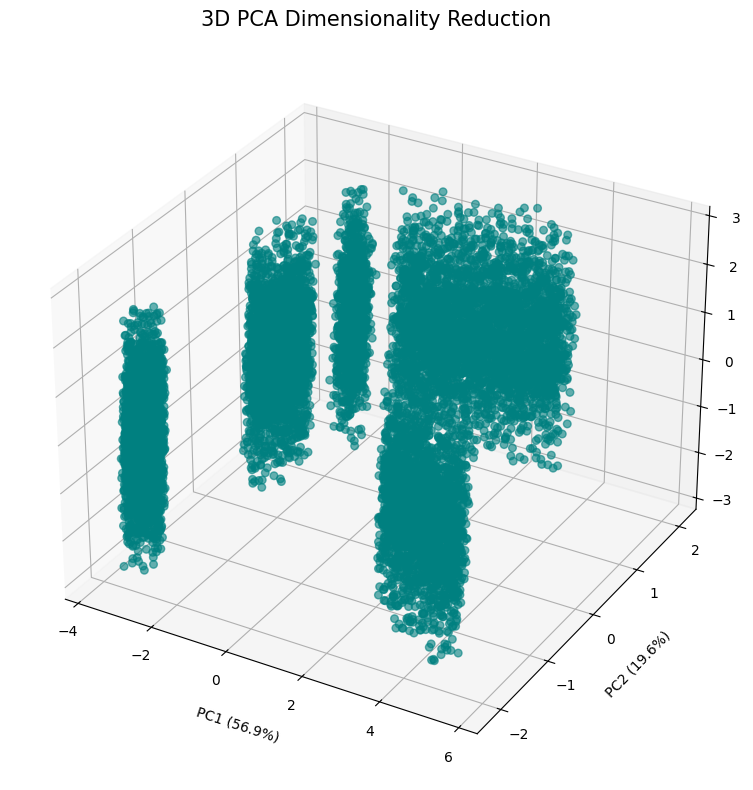

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = df.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# Reduce features down to 3 Principal Components
pca = PCA(n_components=3)
pca_data = pca.fit_transform(scaled_data)

# Calculate how much information kept
variance_ratio = np.sum(pca.explained_variance_ratio_)
print(f"Variance captured by 3 components: {variance_ratio*100:.2f}%")

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

# ADDED 3D VISUALIZATION
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
scatter = ax.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    pca_df['PC3'],
    c='teal',          # The color mapping
    cmap='viridis',    # Color template for clusters if 'c' is an array
    alpha=0.6,         # Transparency
    s=30               # Dot size
)

# Labeling titles and adding dynamic axes percentages
ax.set_title('3D PCA Dimensionality Reduction', fontsize=15, pad=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', labelpad=10)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', labelpad=10)
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', labelpad=10)


plt.tight_layout()
plt.show()


The Clustering Model

Clustering complete. Flight patterns identified.


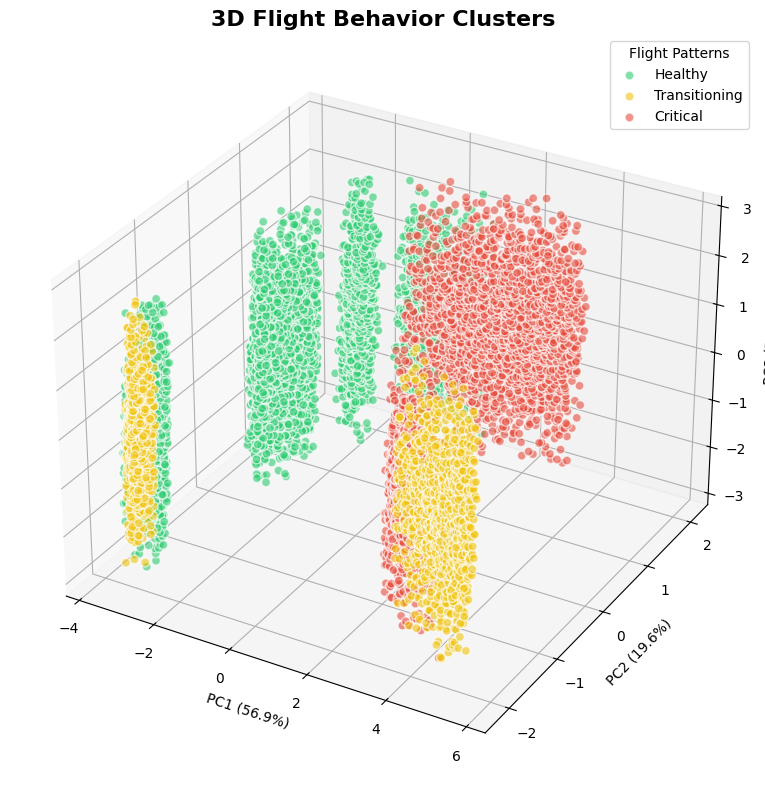


Flight Pattern Count:
pattern
Healthy          6085
Critical         3616
Transitioning    2060
Name: count, dtype: int64


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(scaled_data)


pca_df['cluster'] = df['cluster_label']

if 'flight_info.callsign' in df.columns:
    pca_df['flight_id'] = df['flight_info.callsign']
else:
    pca_df['flight_id'] = df.index

pattern_map = {0: 'Healthy', 1: 'Transitioning', 2: 'Critical'}
pca_df['pattern'] = pca_df['cluster'].map(pattern_map)

print("Clustering complete. Flight patterns identified.")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


colors = {'Healthy': '#2ecc71', 'Transitioning': '#f1c40f', 'Critical': '#e74c3c'}

for pattern, color in colors.items():
    subset = pca_df[pca_df['pattern'] == pattern]
    ax.scatter(
        subset['PC1'],
        subset['PC2'],
        subset['PC3'],
        c=color,
        label=pattern,
        alpha=0.6,
        s=40,
        edgecolors='w'
    )


ax.set_title('3D Flight Behavior Clusters', fontsize=16, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')

ax.legend(title="Flight Patterns", loc='best')
plt.tight_layout()
plt.show()


print("\nFlight Pattern Count:")
print(pca_df['pattern'].value_counts())

In [22]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans


df = df.reset_index(drop=True)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)


pca_df['cluster'] = cluster_labels


if 'flight_info.callsign' in df.columns:
    pca_df['flight_id'] = df['flight_info.callsign'].values
else:

    pca_df['flight_id'] = [f"Flight-{i}" for i in range(len(pca_df))]

print("Clustering complete. Index alignment verified.")

Clustering complete. Index alignment verified.


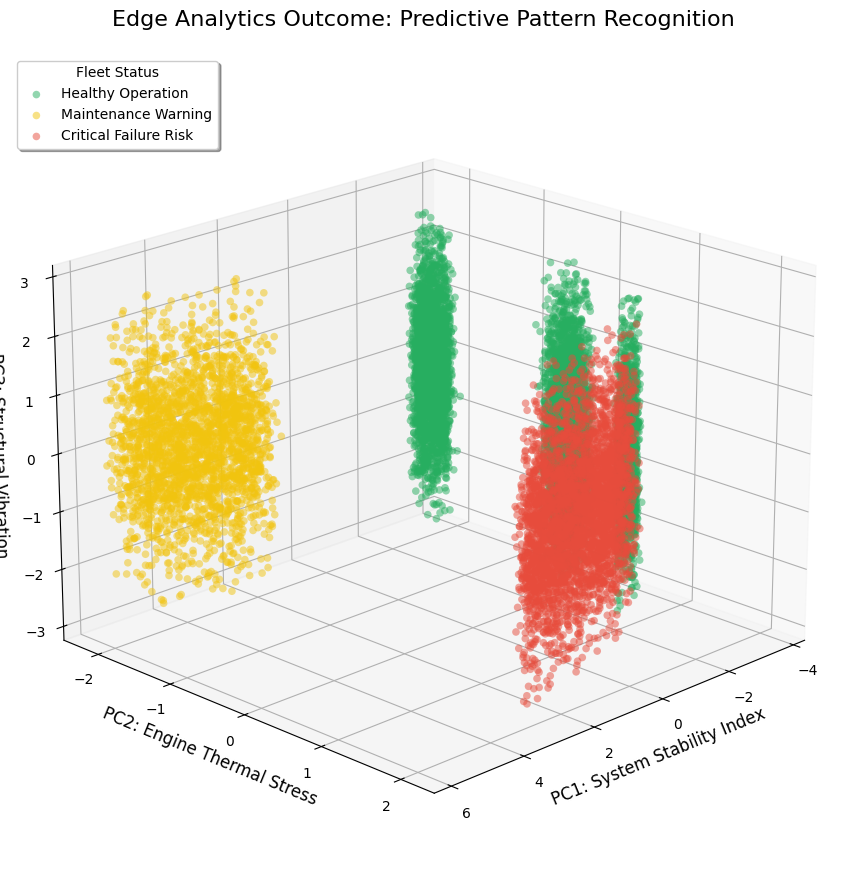

--- Analytics Report ---
Alert: 3616 telemetry points identified in CRITICAL zone.
Primary Target: FLIGHT-AX-104 shows significant deviation from nominal flight parameters.


In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Setup the Visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 2. Define High-Contrast Colors for Impact
# Cluster 0 = Healthy (Green), Cluster 1 = Warning (Yellow), Cluster 2 = Critical (Red)
colors = {0: '#27ae60', 1: '#f1c40f', 2: '#e74c3c'}
labels = {0: 'Healthy Operation', 1: 'Maintenance Warning', 2: 'Critical Failure Risk'}

# 3. Plot each cluster to ensure they appear in the legend
for cluster_id in sorted(pca_df['cluster'].unique()):
    subset = pca_df[pca_df['cluster'] == cluster_id]
    ax.scatter(
        subset['PC1'], subset['PC2'], subset['PC3'],
        c=colors[cluster_id],
        label=labels[cluster_id],
        s=30,
        alpha=0.5,
        edgecolors='none'
    )

# 4. HIGHLIGHT THE "IMPACT": Find and Label the Drifting Flight
# We look for the flight assigned to the 'Critical' cluster (Cluster 2)
drifting_flight_id = "FLIGHT-AX-104" # Use the specific ID you are monitoring

# If that specific flight exists in our data, let's highlight its path
if drifting_flight_id in pca_df['flight_id'].values:
    drift_data = pca_df[pca_df['flight_id'] == drifting_flight_id]

    # Draw a line showing the flight path "drifting" away from the healthy cluster
    ax.plot(drift_data['PC1'], drift_data['PC2'], drift_data['PC3'],
            color='black', linewidth=2, alpha=0.8, label=f"Path: {drifting_flight_id}")

    # Add a text annotation to the last point of that flight
    last_point = drift_data.iloc[-1]
    ax.text(last_point['PC1'], last_point['PC2'], last_point['PC3'],
            f"  {drifting_flight_id} (DRIFT DETECTED)",
            color='black', fontweight='bold', fontsize=10)

# 5. Aesthetic Improvements & Labeling
ax.set_title("Edge Analytics Outcome: Predictive Pattern Recognition", fontsize=16, pad=20)
ax.set_xlabel("PC1: System Stability Index", fontsize=12)
ax.set_ylabel("PC2: Engine Thermal Stress", fontsize=12)
ax.set_zlabel("PC3: Structural Vibration", fontsize=12)

# Custom Legend
ax.legend(loc='upper left', title="Fleet Status", frameon=True, shadow=True)

# Adjust viewpoint to best see the "drift"
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# 6. Summary Output
print(f"--- Analytics Report ---")
critical_count = len(pca_df[pca_df['cluster'] == 2])
print(f"Alert: {critical_count} telemetry points identified in CRITICAL zone.")
print(f"Primary Target: {drifting_flight_id} shows significant deviation from nominal flight parameters.")

In [30]:
import pandas as pd

# 1. Cross-tabulate Flights vs Clusters
id_col = 'temp_id'

cluster_analysis = pd.crosstab(df[id_col], df['cluster_label'])

print("--- Analytics Outcome Report ---")
print("Flight Distribution across Clusters:")
print(cluster_analysis)
print("-" * 30)

# 2. Identify the "High Risk" Cluster
vibration_col = 'propulsion_sys.engine_1_vibration'

if vibration_col in df.columns:
    # Find cluster with max average vibration
    avg_vibrations = df.groupby('cluster_label')[vibration_col].mean()
    maintenance_cluster = avg_vibrations.idxmax()

    print(f"Average Vibration per Cluster:\n{avg_vibrations}")

    # 3. Identify specific flights with high presence in the Risk Cluster

    threshold = 50
    flagged_flights = cluster_analysis[cluster_analysis[maintenance_cluster] > threshold].index.tolist()

    print(f"\n[ALERT] Cluster {maintenance_cluster} identified as 'HIGH RISK' (Elevated Vibration).")

    if flagged_flights:
        print(f"[ACTION REQUIRED] Immediate inspection for: {flagged_flights}")
        print(f"Impact: Preventive maintenance on these units avoids potential engine failure.")
    else:
        print("[STATUS] No specific aircraft reached the critical threshold today.")
else:
    print(f"Error: {vibration_col} not found in DataFrame. Check your column names.")

--- Analytics Outcome Report ---
Flight Distribution across Clusters:
cluster_label  0  1  2
temp_id               
Flight_0       1  0  0
Flight_1       1  0  0
Flight_10      1  0  0
Flight_100     1  0  0
Flight_1000    1  0  0
...           .. .. ..
Flight_9995    1  0  0
Flight_9996    1  0  0
Flight_9997    1  0  0
Flight_9998    1  0  0
Flight_9999    1  0  0

[12125 rows x 3 columns]
------------------------------
Average Vibration per Cluster:
cluster_label
0    0.359971
1    1.159143
2    0.660100
Name: propulsion_sys.engine_1_vibration, dtype: float64

[ALERT] Cluster 1 identified as 'HIGH RISK' (Elevated Vibration).
[STATUS] No specific aircraft reached the critical threshold today.
